# 04 - Synthetic MM Behavior Models
Create synthetic signatures for Good/Gaming/Stressed MM archetypes and visualize their 'fingerprints'.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

In [2]:
archetypes = pd.DataFrame([
    {'model': 'Good MM', 'spread_pct': 0.25, 'depth_1pct_usd': 750000, 'quote_presence_pct': 99.5, 'resilience_min': 1.2},
    {'model': 'Gaming MM', 'spread_pct': 0.50, 'depth_1pct_usd': 20000, 'quote_presence_pct': 99.0, 'resilience_min': 4.0},
    {'model': 'Stressed MM', 'spread_pct': 0.40, 'depth_1pct_usd': 350000, 'quote_presence_pct': 96.5, 'resilience_min': 14.0},
])

# Normalize for radar plot
cols = ['spread_pct', 'depth_1pct_usd', 'quote_presence_pct', 'resilience_min']
df_norm = archetypes.copy()
df_norm['spread_pct'] = 1 / df_norm['spread_pct'] # Higher is better for radar
df_norm['resilience_min'] = 1 / df_norm['resilience_min'] # Higher is better

for col in cols:
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min() + 1e-9)

display(archetypes)

,model,spread_pct,depth_1pct_usd,quote_presence_pct,resilience_min
0,Good MM,0.25,750000,99.5,1.2
1,Gaming MM,0.50,20000,99.0,4.0
2,Stressed MM,0.40,350000,96.5,14.0


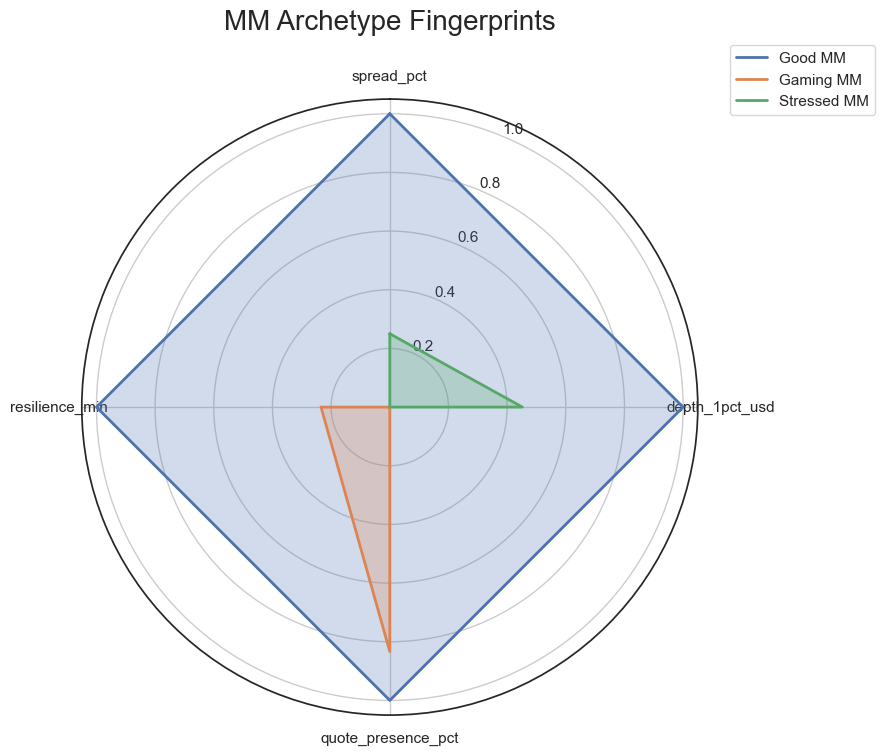

In [3]:
def make_radar_chart(df, labels, title):
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for i, row in df.iterrows():
        values = row[labels].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=row['model'])
        ax.fill(angles, values, alpha=0.25)
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    plt.title(title, size=20, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

labels = ['Spread Efficiency', 'Depth', 'Uptime', 'Resilience']
make_radar_chart(df_norm, cols, "MM Archetype Fingerprints")